In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import train_test_split,GridSearchCV
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')

In [2]:
clg_details=pd.read_csv(filepath_or_buffer="college_list.csv")
clg_details

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


#### DATA UNDERSTANDING

In [3]:
clg_details.dtypes

College_Name              object
Student_Faculty_Ratio      int64
Annual_Fees_INR            int64
Placement_Percentage       int64
Average_Package_LPA      float64
Infrastructure_Score       int64
dtype: object

In [4]:
clg_details.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


In [5]:
clg_details.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

#### DATA PREPARATION

In [6]:
X=clg_details.drop(labels="College_Name",axis=1)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


##### Apply data transportation techniques:

In [7]:
scaler=StandardScaler()
x_scaler=scaler.fit_transform(X)
X_scaler=pd.DataFrame(x_scaler)
X_scaler

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [8]:
X_scaler.mean().round(4),X_scaler.std().round(4)

(0    0.0
 1    0.0
 2   -0.0
 3    0.0
 4   -0.0
 dtype: float64,
 0    1.001
 1    1.001
 2    1.001
 3    1.001
 4    1.001
 dtype: float64)

#### MODEL BUILDING

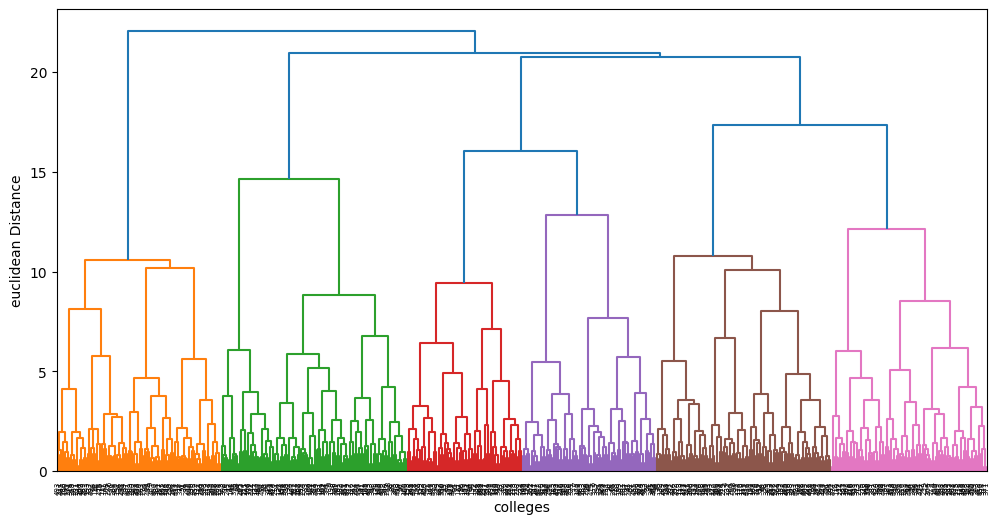

In [9]:
plt.figure(figsize=(12,6))
denogram=sch.dendrogram(sch.linkage(X_scaler,method='ward'))
plt.xlabel("colleges")
plt.ylabel("euclidean Distance")
plt.show()

##### For understanding purpose take only 20 college to visualize

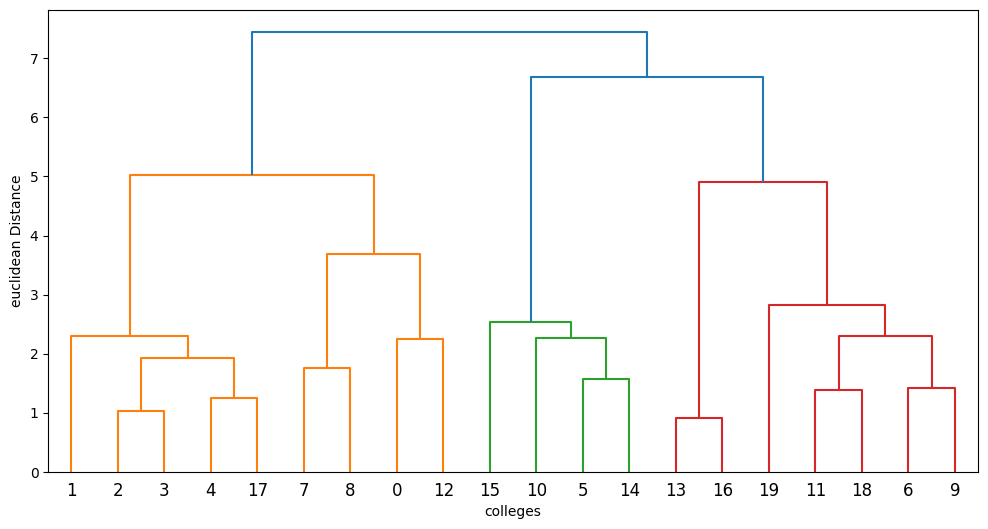

In [10]:
xt_scaler=X_scaler.head(20)
plt.figure(figsize=(12,6))
denogram=sch.dendrogram(sch.linkage(xt_scaler,method='ward'))
plt.xlabel("colleges")
plt.ylabel("euclidean Distance")
plt.show()

##### Apply agglomerative clustering(Based on denogram,assume 3 clusters)

In [11]:
hr=AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='ward')
clusters=hr.fit_predict(X_scaler)
clusters

array([2, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 2, 0, 0, 2, 0, 1, 1, 0, 2,
       2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 2, 2, 0, 1, 0, 2, 1, 0, 1, 0, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 2,
       0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 1, 1, 2,
       0, 2, 1, 0, 0, 0, 0, 1, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 2, 0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 0, 0, 0, 0,
       2, 0, 0, 1, 1, 2, 0, 2, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 0, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 2, 0, 0,
       1, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 2, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0,

##### Attach clusters to Dataset

In [12]:
clg_details["College_level"]=clusters
clg_details

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


In [13]:
x=clg_details.drop('College_Name',axis=1)
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_level
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,0
...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0
496,12,39111,76,3.62,7,0
497,16,199182,64,3.88,3,1
498,10,46389,77,9.31,6,0


In [14]:
x.groupby('College_level').agg("mean")

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
College_level,,,,,
0,20.407051,121853.471154,67.278846,6.954583,6.509615
1,17.159091,156795.136364,85.568182,5.565682,3.965909
2,11.650000,175656.000000,59.790000,8.362500,6.080000


In [15]:
x.groupby('College_level').agg("min","max")

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
College_level,,,,,
0,8,30404,40,2.00,3
1,8,39337,64,2.09,3
2,8,49065,40,2.01,3


In [16]:
cluster_names={0:"BEST CLG",
               1:"MID-LEVEL CLG",
               2:"LOWER-LEVEL CLG"}
x["category"]=x["College_level"].map(cluster_names)
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_level,category
0,14,113042,59,9.20,8,2,LOWER-LEVEL CLG
1,27,115999,67,3.07,7,0,BEST CLG
2,22,47955,50,3.40,9,0,BEST CLG
3,18,67841,43,4.64,8,0,BEST CLG
4,15,100640,54,4.66,9,0,BEST CLG
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,BEST CLG
496,12,39111,76,3.62,7,0,BEST CLG
497,16,199182,64,3.88,3,1,MID-LEVEL CLG
498,10,46389,77,9.31,6,0,BEST CLG


#### DATA SPLITTING

In [17]:
input=x.drop(["College_level","category"],axis=1)
input

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


In [18]:
output=x["College_level"]
output

0      2
1      0
2      0
3      0
4      0
      ..
495    0
496    0
497    1
498    0
499    0
Name: College_level, Length: 500, dtype: int64

In [19]:
x_train,x_test,y_train,y_test=train_test_split(input,output,test_size=None,random_state=25,shuffle=True,stratify=output)
x_train,x_test,y_train,y_test

(     Student_Faculty_Ratio  Annual_Fees_INR  Placement_Percentage  \
 396                     17           240176                    71   
 197                     19           127007                    44   
 471                     18           105703                    64   
 313                     21           105745                    59   
 275                     11            44489                    65   
 ..                     ...              ...                   ...   
 193                      8           108752                    75   
 295                     13            45254                    45   
 391                     15           148831                    67   
 27                      23           211589                    59   
 341                     15           167326                    53   
 
      Average_Package_LPA  Infrastructure_Score  
 396                 4.04                     6  
 197                 7.71                     7  
 471    

#### MODEL TRAINING

In [32]:
rf_classifier=RandomForestClassifier()
grid=GridSearchCV(estimator=rf_classifier,param_grid={"max_depth":[3,5,7,9],
                                                      "n_estimators":[50,75,85,100],
                                                      "criterion":['gini','entopy']})
grid.fit(x_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entopy'], 'max_depth': [3, 5, ...], 'n_estimators': [50, 75, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


#### MODEL TESTING

##### TRAINING ACCURACY

In [33]:
y_pred_train=grid.predict(x_train)
y_pred_train

array([0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 1, 0, 1, 2, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 1, 0, 1, 0, 2, 1, 1, 0, 2, 0,
       0, 1, 2, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1,
       2, 1, 0, 1, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 2, 0, 0, 1, 1,
       2, 0, 0, 0, 2, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1,
       0, 2, 0, 2, 0, 0, 1, 1, 2, 0, 2, 0, 0, 1, 0, 2, 0, 0, 0, 0, 2, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 1, 1, 2, 2, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 1, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 1,
       0, 2, 0, 0, 0, 2, 1, 1, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2,
       2, 1, 1, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 2, 0,

In [34]:
y_pred_test=grid.predict(x_test)
y_pred_test

array([0, 0, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       2, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0,
       0, 0, 2, 0, 1, 0, 2, 2, 0, 0, 0, 2, 0, 1, 0, 2, 2, 2, 1, 0, 2, 0,
       0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1])

#### MODEL EVALUATION

##### TRAINING ACCURACY SCORE

In [35]:
print("Accuracy score:",accuracy_score(y_train,y_pred_train))
print(classification_report(y_train,y_pred_train))
print(confusion_matrix(y_train,y_pred_train))

Accuracy score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00        66
           2       1.00      1.00      1.00        75

    accuracy                           1.00       375
   macro avg       1.00      1.00      1.00       375
weighted avg       1.00      1.00      1.00       375

[[234   0   0]
 [  0  66   0]
 [  0   0  75]]


##### TEST ACCURACY SCORE

In [36]:
print("Accuracy score:",accuracy_score(y_test,y_pred_test))
print(classification_report(y_test,y_pred_test))
print(confusion_matrix(y_test,y_pred_test))

Accuracy score: 0.888
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        78
           1       0.94      0.77      0.85        22
           2       0.89      0.64      0.74        25

    accuracy                           0.89       125
   macro avg       0.90      0.80      0.84       125
weighted avg       0.89      0.89      0.88       125

[[78  0  0]
 [ 3 17  2]
 [ 8  1 16]]


#### THE END

======================================================================================================================================